### Replicando para BR

In [1]:
# pip install yfinance pandas requests lxml openpyxl

import re
import time
import math
import requests
import pandas as pd
import yfinance as yf

HEADERS = {"User-Agent": "Mozilla/5.0"}

# ========= 1) Pegar universo (IBrX 100 ou Ibovespa) =========
def fetch_index_tickers(index: str = "IBRX") -> list[str]:
    """
    index:
      - "IBRX" -> IBrX 100 (carteira teórica)
      - "IBOV" -> Ibovespa (carteira teórica)
    Fonte: site antigo BM&FBOVESPA/B3 (bem parseável)
    """
    index = index.upper().strip()
    if index not in {"IBRX", "IBOV"}:
        raise ValueError("index deve ser 'IBRX' (IBrX 100) ou 'IBOV' (Ibovespa)")

    url = f"https://bvmf.bmfbovespa.com.br/indices/ResumoCarteiraTeorica.aspx?Indice={index}&idioma=pt-br"
    html = requests.get(url, headers=HEADERS, timeout=30).text

    # Tenta primeiro via read_html
    tickers = []
    try:
        tables = pd.read_html(html)
        for tb in tables:
            cols = [str(c).lower() for c in tb.columns]
            # geralmente a 1a coluna é "Código"
            if any("código" in c or "codigo" in c for c in cols):
                col = tb.columns[0]
                tickers = (
                    tb[col].astype(str)
                    .str.upper().str.strip()
                    .tolist()
                )
                break
    except ValueError:
        pass

    # Fallback por regex (pega coisas tipo PETR4, BPAC11, KLBN11 etc.)
    if not tickers:
        tickers = re.findall(r"\b[A-Z]{4}\d{1,2}\b", html)

    # Filtra e remove duplicatas mantendo ordem
    seen = set()
    out = []
    for t in tickers:
        t = t.strip().upper()
        if re.match(r"^[A-Z]{4}\d{1,2}$", t) and t not in seen:
            seen.add(t)
            out.append(t)

    return out

def to_yahoo_sa(tickers_b3: list[str]) -> list[str]:
    return [f"{t}.SA" if not t.endswith(".SA") else t for t in tickers_b3]


# ========= 2) Baixar preços (Close ajustado) em lotes =========
def chunked(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]

def extract_close(df: pd.DataFrame, tickers_sa: list[str]) -> pd.DataFrame:
    """
    Normaliza a saída do yf.download para sempre retornar um DataFrame
    com colunas = tickers e valores = Close.
    """
    if df is None or df.empty:
        return pd.DataFrame()

    # Caso multi-ticker: geralmente vem MultiIndex com nível "Close"
    if isinstance(df.columns, pd.MultiIndex):
        # tenta no formato df["Close"]
        if "Close" in df.columns.get_level_values(0):
            close = df["Close"].copy()
            # garante só os tickers pedidos (às vezes vem coisa extra)
            close = close.loc[:, [c for c in close.columns if c in tickers_sa]]
            return close

        # fallback: procura nível com "Close"
        for level in range(df.columns.nlevels):
            if "Close" in df.columns.get_level_values(level):
                # tenta selecionar onde esse nível == Close
                close_cols = [c for c in df.columns if "Close" in c]
                close = df.loc[:, close_cols].copy()
                return close

    # Caso single-ticker
    if "Close" in df.columns:
        # Descobre ticker único (quando você passa 1 ativo)
        # e cria DF com coluna = ticker
        # Se não souber, usa "SINGLE"
        colname = tickers_sa[0] if tickers_sa else "SINGLE"
        return df[["Close"]].rename(columns={"Close": colname})

    return pd.DataFrame()

def download_closes(tickers_sa: list[str], start: str, end: str,
                    batch_size: int = 25, max_retries: int = 3, delay: int = 3) -> tuple[pd.DataFrame, list[str]]:
    """
    Baixa Close ajustado (auto_adjust=True) para uma lista de tickers .SA em lotes.
    Retorna (close_df, failures)
    """
    all_close = []
    failures = []

    for batch in chunked(tickers_sa, batch_size):
        got = None
        for attempt in range(1, max_retries + 1):
            try:
                df = yf.download(
                    tickers=batch,
                    start=start,
                    end=end,
                    auto_adjust=True,   # usa preços ajustados do Yahoo
                    progress=False,
                    threads=True,
                    timeout=30,
                    group_by="column"
                )
                got = extract_close(df, batch)
                break
            except Exception:
                if attempt == max_retries:
                    got = pd.DataFrame()
                else:
                    time.sleep(delay)

        # Se vier vazio, marca todos do batch como falha
        if got is None or got.empty:
            failures.extend(batch)
        else:
            # identifica tickers que não vieram
            missing = [t for t in batch if t not in got.columns]
            failures.extend(missing)
            # mantém só colunas ok
            got = got.loc[:, [c for c in got.columns if c in batch]]
            all_close.append(got)

    if not all_close:
        return pd.DataFrame(), sorted(set(failures))

    close_df = pd.concat(all_close, axis=1)
    # remove colunas duplicadas (se acontecer)
    close_df = close_df.loc[:, ~close_df.columns.duplicated()]
    close_df = close_df.sort_index()
    return close_df, sorted(set(failures))


def save_prices_csv(close_df: pd.DataFrame, filepath: str):
    close_df.to_csv(filepath, index=True)



In [8]:

# Escolha do universo (tanto faz, você disse): "IBRX" ou "IBOV"
#INDEX = "IBRX"  # recomendo IBrX 100
INDEX = "IBOV"

tickers_b3 = fetch_index_tickers(INDEX)
tickers_sa = to_yahoo_sa(tickers_b3)

print(f"Universo {INDEX}: {len(tickers_sa)} tickers")

# Períodos
start = "1997-01-02"

# 1997–2007 (end exclusivo)
end_2007 = "2008-01-01"
close_9707, fail_9707 = download_closes(tickers_sa, start, end_2007, batch_size=25)
print(f"[INFO] Tickers sem dados no Yahoo: {len(fail_9707)}")
save_prices_csv(close_9707, "precos_1997_2007.csv")
print("Salvo: precos_1997_2007.csv")

# 1997–2025 (end exclusivo)
end_2025 = "2026-01-01"
close_9725, fail_9725 = download_closes(tickers_sa, start, end_2025, batch_size=20)
print(f"[INFO] Tickers sem dados no Yahoo: {len(fail_9725)}")
save_prices_csv(close_9725, "precos_1997_2025.csv")
print("Salvo: precos_1997_2025.csv")

C:\Users\savio\AppData\Local\Temp\ipykernel_8640\1243103092.py:30: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


Universo IBOV: 81 tickers



15 Failed downloads:
['CCRO3.SA', 'BRFS3.SA', 'CIEL3.SA', 'CRFB3.SA', 'BTOW3.SA', 'BRML3.SA', 'BRDT3.SA', 'CPLE6.SA']: YFTzMissingError('possibly delisted; no timezone found')
['ASAI3.SA', 'BBSE3.SA', 'COGN3.SA', 'BPAC11.SA', 'AZUL4.SA', 'BBDC4.SA', 'CVCB3.SA']: YFPricesMissingError('possibly delisted; no price data found  (1d 1997-01-02 -> 2008-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 852170400, endDate = 1199152800")')
Failed to get ticker 'EMBR3.SA' reason: Failed to perform, curl: (28) Operation timed out after 10016 milliseconds with 0 bytes received. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
Failed to get ticker 'HGTX3.SA' reason: Failed to perform, curl: (28) Connection timed out after 10007 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
Failed to get ticker 'IGTA3.SA' reason: Failed to perform, curl: (28) Operation timed out after 10006 milliseconds with 0 bytes received. See https://cur

[INFO] Tickers sem dados no Yahoo: 6
Salvo: precos_1997_2007.csv


Failed to get ticker 'ENBR3.SA' reason: Failed to perform, curl: (6) Could not resolve host: query2.finance.yahoo.com. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
Failed to get ticker 'GNDI3.SA' reason: Failed to perform, curl: (6) Could not resolve host: query2.finance.yahoo.com. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
Failed to get ticker 'ELET3.SA' reason: Failed to perform, curl: (6) Could not resolve host: query2.finance.yahoo.com. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.

20 Failed downloads:
['EMBR3.SA', 'CRFB3.SA', 'ELET6.SA', 'ENBR3.SA', 'GNDI3.SA', 'CPLE6.SA', 'ELET3.SA']: YFTzMissingError('possibly delisted; no timezone found')
['CYRE3.SA', 'GGBR4.SA', 'EZTC3.SA', 'EGIE3.SA', 'FLRY3.SA', 'EQTL3.SA', 'GOAU4.SA', 'ECOR3.SA', 'CSAN3.SA', 'ENEV3.SA', 'ENGI11.SA', 'CSNA3.SA', 'CVCB3.SA']: DNSError('Failed to perform, curl: (6) Could not resolve host: query2.finance.yahoo.com. See http

[INFO] Tickers sem dados no Yahoo: 60
Salvo: precos_1997_2025.csv


In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import bs4 as bs
import requests
import seaborn as sns
import requests
import time

from funcoes2 import (
    pca_portfolio_spy,
    pca_portfolio_spy_hedge,
    stats_from_returns,
    pca_portfolio_spy_adaptive_pcs
)

from analise_estrategia import analyze_strategy 

In [ ]:
import investpy

# Pega TODAS as ações listadas no Brasil
stocks_br = investpy.stocks.get_stocks(country='brazil')

# Ver o DataFrame
print(stocks_br.head()) 

# Extrair símbolos
tickers = stocks_br['symbol'].tolist()

# Converter para formato yfinance
tickers_yf = [t + '.SA' for t in tickers]

print(f"Total: {len(tickers_yf)} ações")

  country           name                               full_name  \
0  brazil  ABC BRASIL PN                     Banco ABC Brasil SA   
1  brazil  BRASILAGRO ON                   BrasilAgro - Co ON NM   
2  brazil     RUMO ON NM  RUMO Logistica Operadora Multimodal SA   
3  brazil  ALPARGATAS ON                           Alpargatas SA   
4  brazil  ALPARGATAS PN                           Alpargatas SA   

           isin currency symbol  
0  BRABCBACNPR4      BRL  ABCB4  
1  BRAGROACNOR7      BRL  AGRO3  
2  BRRAILACNOR9      BRL  RAIL3  
3  BRALPAACNOR0      BRL  ALPA3  
4  BRALPAACNPR7      BRL  ALPA4  
Total: 749 ações


In [9]:
# Carregar dados
start_date = "2000-01-03"
end_date = "2007-12-31"

data = pd.read_csv("precos_1997_2007.csv", index_col=0)
data.index = pd.to_datetime(data.index)
data = data.sort_index()

returns = data.pct_change()
returns.dropna(inplace=True,axis=0, how='all')
returns.dropna(inplace=True,axis=1, how='any')
#returns = returns.loc[start_date:end_date]

# Ibovespa no Yahoo é ^BVSP
data_ibov = yf.download("^BVSP", start=start_date, end=end_date, auto_adjust=True, progress=False)["Close"]
data_ibov.index = pd.to_datetime(data_ibov.index).tz_localize(None)
data_ibov = data_ibov.sort_index()

returns_ibov = data_ibov.pct_change().dropna()
returns_ibov.name = "IBOV"

# Garantir que ambos os DataFrames tenham índices coerentes e ordenados (sem timezone)
returns.index     = pd.to_datetime(returns.index).tz_localize(None)
returns_ibov.index = pd.to_datetime(returns_ibov.index).tz_localize(None)
returns     = returns.sort_index()
returns_ibov = returns_ibov.sort_index()

C:\Users\savio\AppData\Local\Temp\ipykernel_8640\832888748.py:9: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change()


In [10]:
# pegar os tickers e atualizar os dados até 2025
tickers = data.columns.tolist()
len(tickers)

75

In [11]:
returns.head()

,BBAS3.SA,BBDC3.SA,BRAP4.SA,BRKM5.SA,CMIG4.SA,CPFE3.SA,CSNA3.SA,GGBR4.SA,SBSP3.SA
Date,,,,,,,,,
2000-01-04,-0.047562,-0.072727,-0.071428,-0.024719,-0.050077,0.181819,0.014389,-0.023093,-0.059287
2000-01-05,0.010244,0.033987,0.076923,0.004608,0.005435,0.000000,0.053698,0.034192,-0.027828
2000-01-06,0.013942,0.015171,0.000000,0.050459,0.013243,0.000000,0.045192,0.030611,-0.005014
2000-01-07,-0.022500,0.017433,0.000000,0.026201,0.002934,0.076921,-0.006440,0.045545,0.014062
2000-01-10,0.054987,0.004896,0.000000,0.021277,-0.018617,0.014287,0.012037,0.032197,0.063154


Tempo : 2000-03-28 00:00:00
Tempo : 2000-03-29 00:00:00
Tempo : 2000-03-30 00:00:00
Tempo : 2000-03-31 00:00:00
Tempo : 2000-04-03 00:00:00
Tempo : 2000-04-04 00:00:00
Tempo : 2000-04-05 00:00:00
Tempo : 2000-04-06 00:00:00
Tempo : 2000-04-07 00:00:00
Tempo : 2000-04-10 00:00:00
Tempo : 2000-04-11 00:00:00
Tempo : 2000-04-12 00:00:00
Tempo : 2000-04-13 00:00:00
Tempo : 2000-04-14 00:00:00
Tempo : 2000-04-17 00:00:00
Tempo : 2000-04-18 00:00:00
Tempo : 2000-04-19 00:00:00
Tempo : 2000-04-20 00:00:00
Tempo : 2000-04-21 00:00:00
Tempo : 2000-04-24 00:00:00
Tempo : 2000-04-25 00:00:00
Tempo : 2000-04-26 00:00:00
Tempo : 2000-04-27 00:00:00
Tempo : 2000-04-28 00:00:00
Tempo : 2000-05-01 00:00:00
Tempo : 2000-05-02 00:00:00
Tempo : 2000-05-03 00:00:00
Tempo : 2000-05-04 00:00:00
Tempo : 2000-05-05 00:00:00
Tempo : 2000-05-08 00:00:00
Tempo : 2000-05-09 00:00:00
Tempo : 2000-05-10 00:00:00
Tempo : 2000-05-11 00:00:00
Tempo : 2000-05-12 00:00:00
Tempo : 2000-05-15 00:00:00
Tempo : 2000-05-16 0

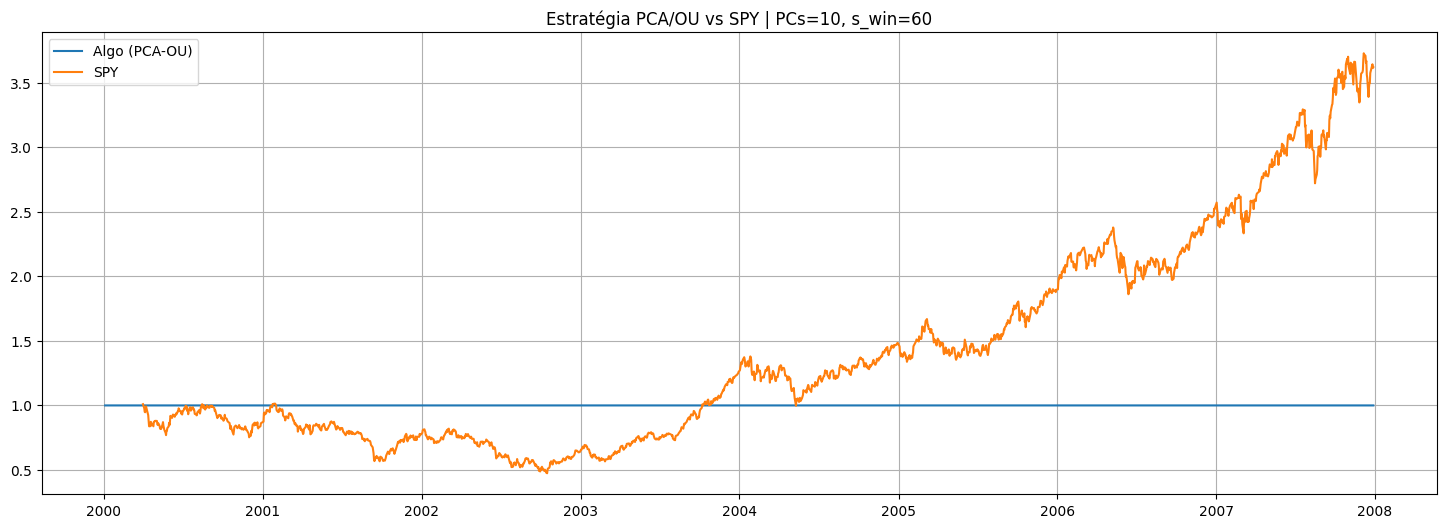

In [12]:
# Melhor

# Rodar experimento 03 : (n = 10, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50, rebalanceamento_dias = 1) (padronizado)
results = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_ibov,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True
)


PERFORMANCE DA ESTRATÉGIA (1999-2007)
  CAGR      :     0.1037 (  10.37%)
  Vol       :     0.3767 (  37.67%)
  Sharpe    :     0.2751 (  27.51%)
  MaxDD     :    -0.5054 ( -50.54%)


🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 
ANÁLISE DE NEUTRALIDADE DA ESTRATÉGIA
🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 


[1/2] Calculando exposição beta agregada...

ESTATÍSTICAS DE EXPOSIÇÃO BETA AGREGADA
         Mean     Std       Min      Max  Mean_Abs
eig1  -0.0533  0.3878   -3.6216   3.0268    0.2418
eig2   0.1163  5.9306 -106.3130  67.0555    1.2135
eig3  -0.2224  6.0725  -70.7283  90.6800    1.2542
eig4   0.1912  3.3816  -34.5052  30.5401    0.8594
eig5   0.6228  6.1843  -38.9906  58.4934    1.5293
eig6  -0.1974  4.0599  -50.5488  48.7867    0.9986
eig7  -0.2339  2.6335  -32.4010  26.0361    0.6329
eig8  -0.0342  0.7725   -8.5063   7.1581    0.3021
eig9  -0.3813  4.9705  -67.1421  38.0544    0.9982
eig10  0.0489  0.7580   -6.0536   8.28

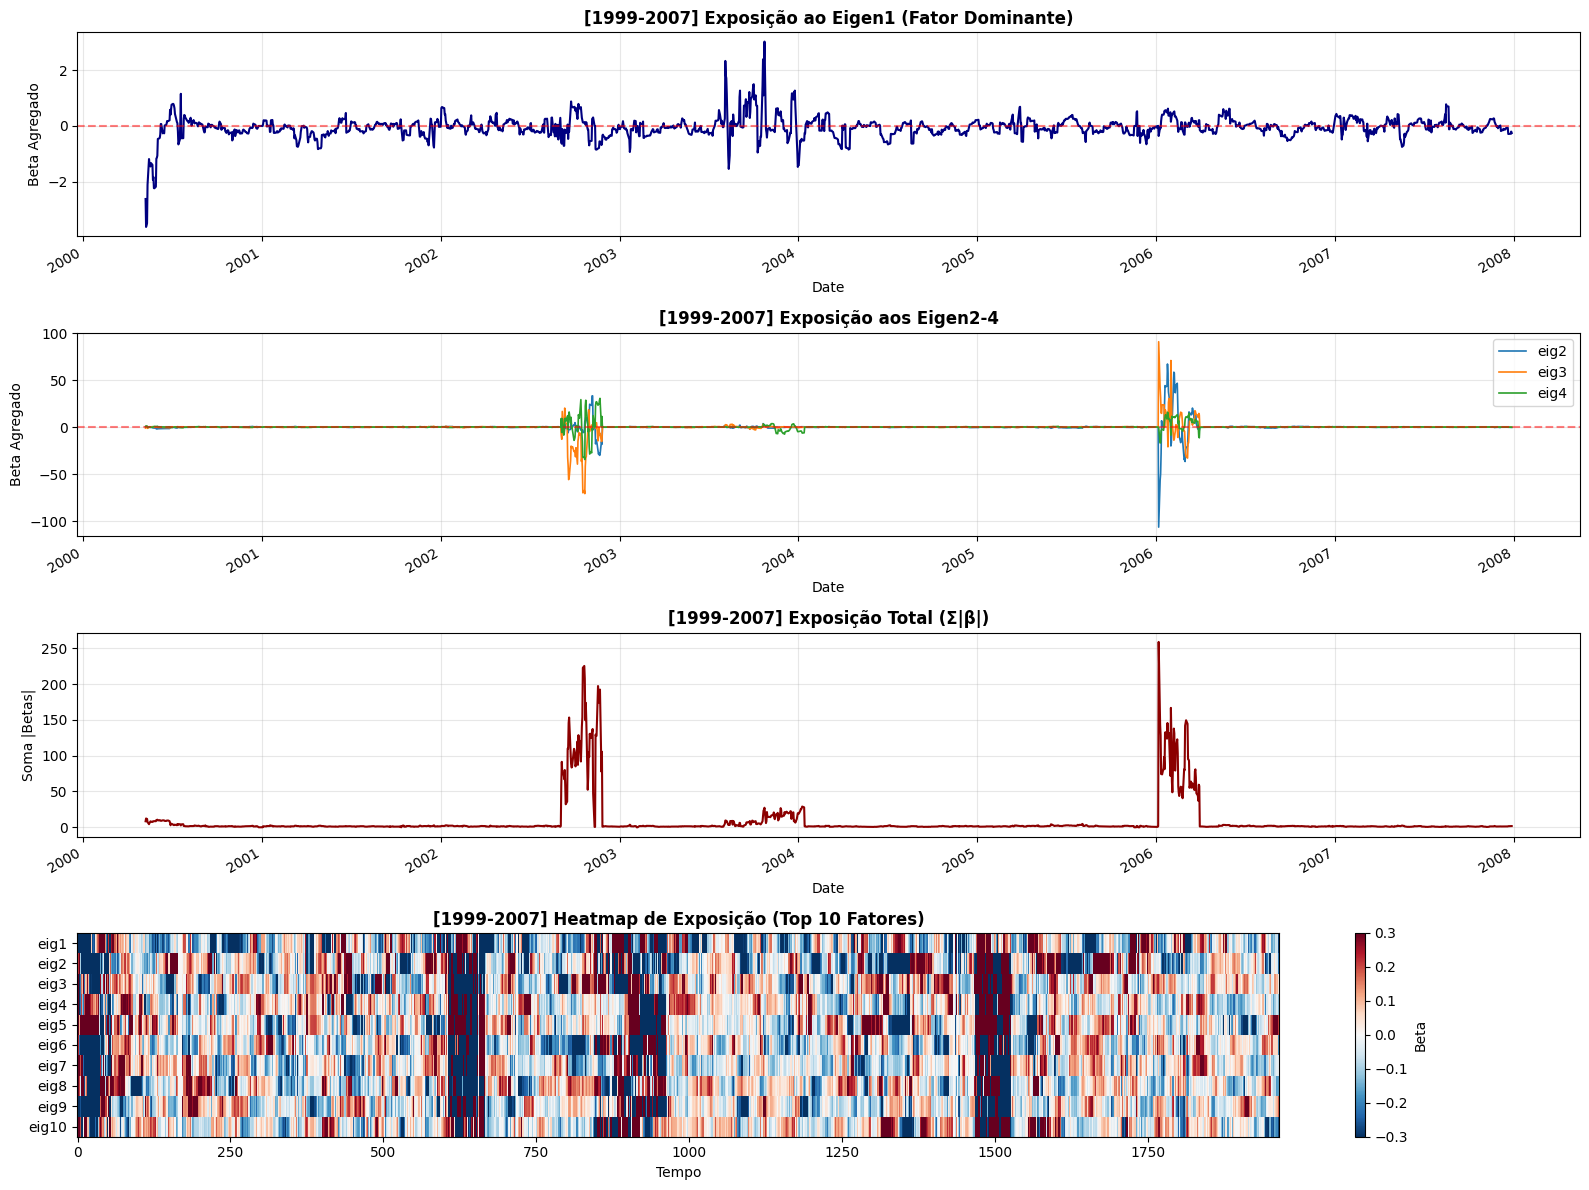


[2/2] Regredindo PnL contra fatores...

REGRESSÃO: RETORNO DA ESTRATÉGIA vs FATORES PCA
  R² (variância explicada por fatores): 0.4522 (45.22%)
  Alpha anualizado (excesso de retorno):  0.0858 (8.58%)
  Alpha diário médio:                      0.000341

  Beta médio (|valor|):                    0.0810
  Beta máximo (|valor|):                   0.4409 (fator: eig10)

📊 Interpretação:
  ❌ PROBLEMA: R² > 15% → Estratégia tem exposição significativa aos fatores!
     Retorno pode ser contaminado por movimentos sistemáticos.

  ✅ Alpha positivo (8.58%/ano) → Estratégia gera valor!


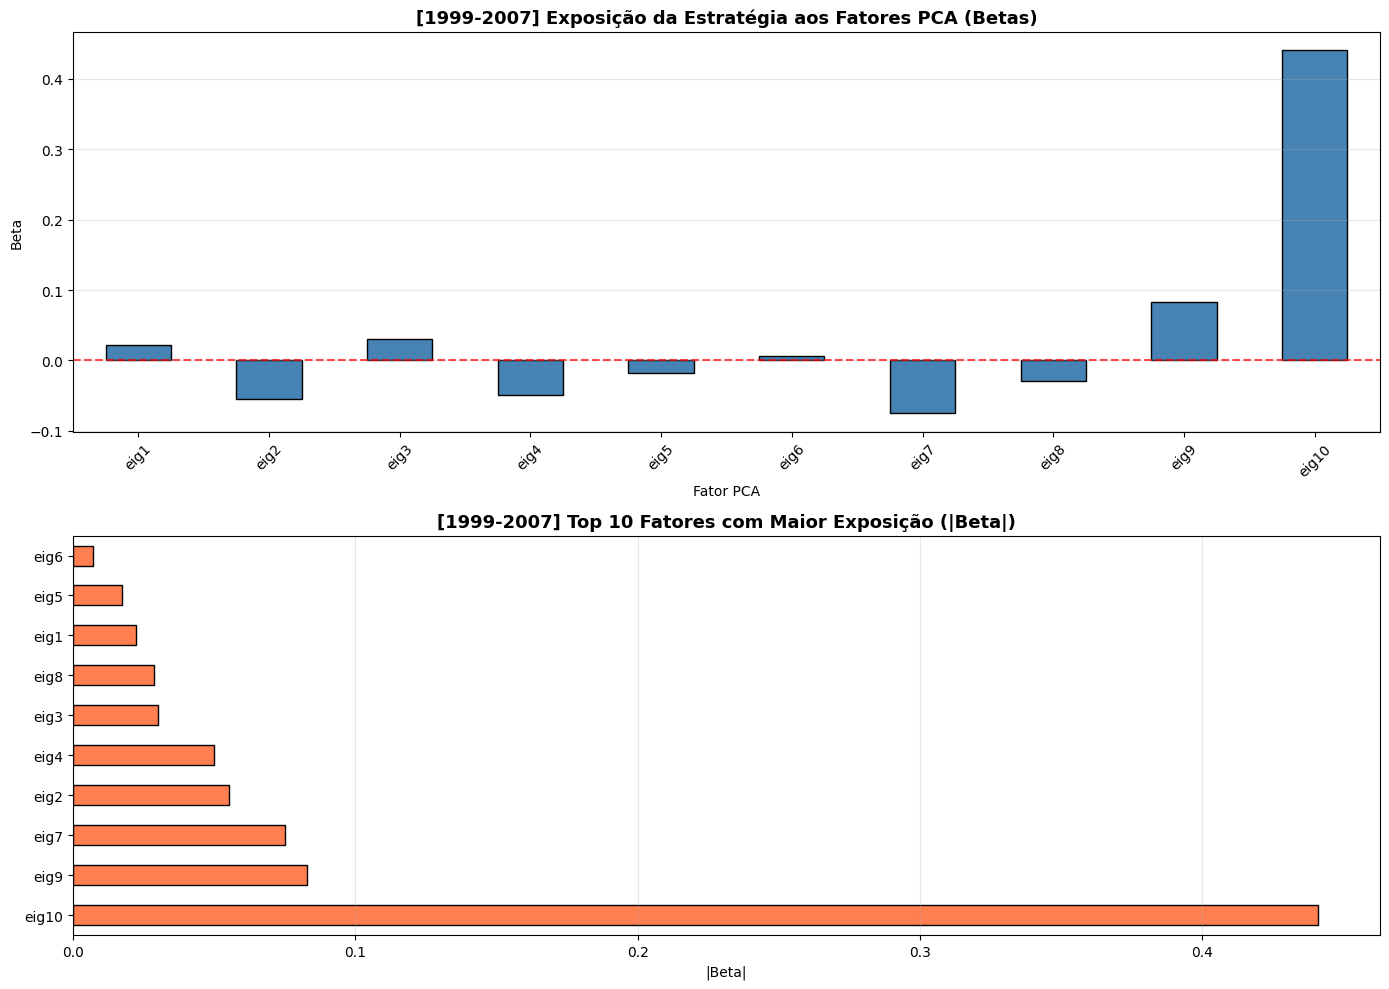


✅ Análise concluída!


📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 
ANÁLISE POR SUBPERÍODOS
📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 


Subperíodo: 1999-2002
  CAGR      :    -0.0982 (  -9.82%)
  Vol       :     0.3057 (  30.57%)
  Sharpe    :    -0.3213 ( -32.13%)
  MaxDD     :    -0.5054 ( -50.54%)

Subperíodo: 2003-2007
  CAGR      :     0.2492 (  24.92%)
  Vol       :     0.4142 (  41.42%)
  Sharpe    :     0.6015 (  60.15%)
  MaxDD     :    -0.4054 ( -40.54%)


In [25]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net = results['ret_net']
stats = stats_from_returns(ret_net)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2007)")
print("="*70)
for k, v in stats.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")

# =============================================================================
# 4. ANÁLISE DE NEUTRALIDADE ⭐ NOVO
# =============================================================================

analysis_results = analyze_strategy(
    algo_weights=results['algo_weights'],
    betas=results['betas'],
    ret_net=results['ret_net'],
    Factor_PCA=results['Factor_PCA'],
    pcs=results['pcs'],
    plot=True,
    title_prefix="[1999-2007] "
)

# =============================================================================
# 5. ANÁLISE POR SUBPERÍODOS (OPCIONAL)
# =============================================================================

print("\n" + "📅 "*35)
print("ANÁLISE POR SUBPERÍODOS")
print("📅 "*35 + "\n")

subperiods = [
    ("1999-2002", "1999-01-01", "2002-12-31"),
    ("2003-2007", "2003-01-01", "2007-12-31"),
]

for label, start, end in subperiods:
    print(f"\n{'='*70}")
    print(f"Subperíodo: {label}")
    print(f"{'='*70}")
    
    mask = (ret_net.index >= start) & (ret_net.index <= end)
    ret_sub = ret_net[mask]
    
    if len(ret_sub) < 100:
        print("⚠️  Dados insuficientes")
        continue
    
    stats_sub = stats_from_returns(ret_sub)
    for k, v in stats_sub.items():
        print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")

In [27]:
# Carregar dados
start_date2 = "2000-01-03"
end_date2 = "2025-12-31"

data_longa = pd.read_csv("precos_1997_2025.csv", index_col=0)
data_longa.index = pd.to_datetime(data_longa.index)
data_longa = data_longa.sort_index()

returns_longa = data_longa.pct_change()
returns_longa.dropna(inplace=True,axis=0, how='all')
returns_longa.dropna(inplace=True,axis=1, how='any')
#returns = returns.loc[start_date:end_date]

# Ibovespa no Yahoo é ^BVSP
data_ibov_longa = yf.download("^BVSP", start=start_date2, end=end_date2, auto_adjust=True, progress=False)["Close"]
data_ibov_longa.index = pd.to_datetime(data_ibov_longa.index).tz_localize(None)
data_ibov_longa = data_ibov_longa.sort_index()

returns_ibov_longa = data_ibov_longa.pct_change().dropna()
returns_ibov_longa.name = "IBOV"

# Garantir que ambos os DataFrames tenham índices coerentes e ordenados (sem timezone)
returns_longa.index     = pd.to_datetime(returns_longa.index).tz_localize(None)
returns_ibov_longa.index = pd.to_datetime(returns_ibov_longa.index).tz_localize(None)
returns_longa     = returns_longa.sort_index()
returns_ibov_longa = returns_ibov_longa.sort_index()

C:\Users\savio\AppData\Local\Temp\ipykernel_18132\1297118825.py:9: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_longa = data_longa.pct_change()


Tempo : 2000-03-28 00:00:00
Tempo : 2000-03-29 00:00:00
Tempo : 2000-03-30 00:00:00
Tempo : 2000-03-31 00:00:00
Tempo : 2000-04-03 00:00:00
Tempo : 2000-04-04 00:00:00
Tempo : 2000-04-05 00:00:00
Tempo : 2000-04-06 00:00:00
Tempo : 2000-04-07 00:00:00
Tempo : 2000-04-10 00:00:00
Tempo : 2000-04-11 00:00:00
Tempo : 2000-04-12 00:00:00
Tempo : 2000-04-13 00:00:00
Tempo : 2000-04-14 00:00:00
Tempo : 2000-04-17 00:00:00
Tempo : 2000-04-18 00:00:00
Tempo : 2000-04-19 00:00:00
Tempo : 2000-04-20 00:00:00
Tempo : 2000-04-21 00:00:00
Tempo : 2000-04-24 00:00:00
Tempo : 2000-04-25 00:00:00
Tempo : 2000-04-26 00:00:00
Tempo : 2000-04-27 00:00:00
Tempo : 2000-04-28 00:00:00
Tempo : 2000-05-01 00:00:00
Tempo : 2000-05-02 00:00:00
Tempo : 2000-05-03 00:00:00
Tempo : 2000-05-04 00:00:00
Tempo : 2000-05-05 00:00:00
Tempo : 2000-05-08 00:00:00
Tempo : 2000-05-09 00:00:00
Tempo : 2000-05-10 00:00:00
Tempo : 2000-05-11 00:00:00
Tempo : 2000-05-12 00:00:00
Tempo : 2000-05-15 00:00:00
Tempo : 2000-05-16 0

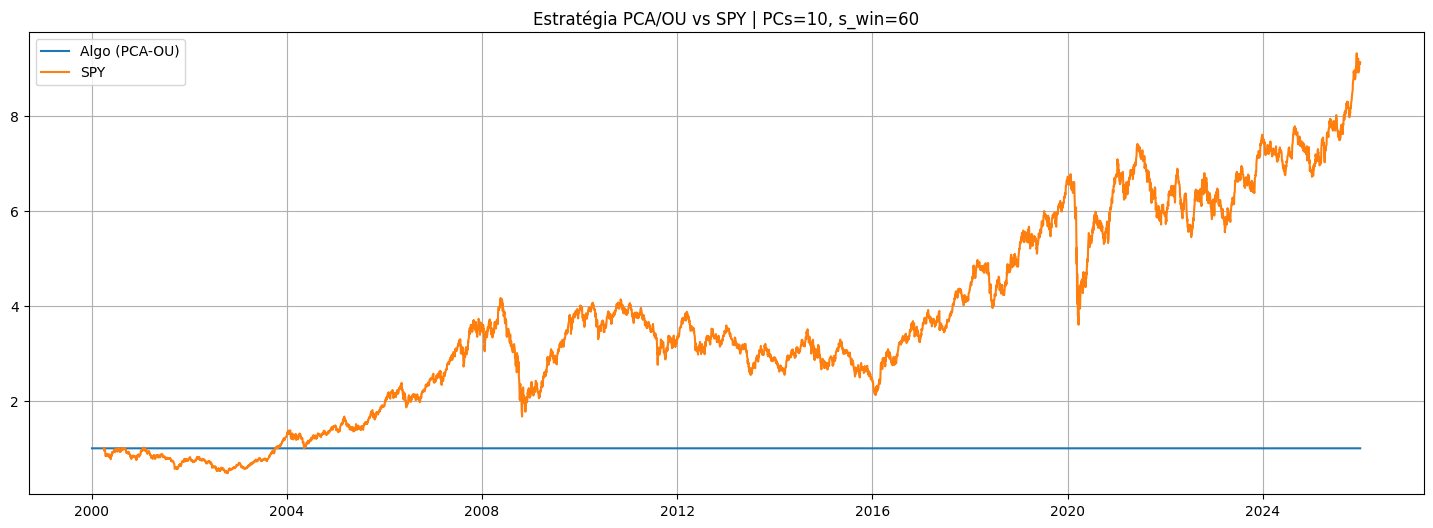

In [28]:
# Melhor longo

# Rodar experimento 03 : (n = 10, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50, rebalanceamento_dias = 1) (padronizado)
results2 = pca_portfolio_spy(
    returns=returns_longa,
    returns_spy=returns_ibov_longa,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True
)


PERFORMANCE DA ESTRATÉGIA (1997-2025)
  CAGR      :     0.0000 (   0.00%)
  Vol       :     0.0000 (   0.00%)
  Sharpe    :        nan (    nan%)
  MaxDD     :     0.0000 (   0.00%)


🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 
ANÁLISE DE NEUTRALIDADE DA ESTRATÉGIA
🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 


[1/2] Calculando exposição beta agregada...

ESTATÍSTICAS DE EXPOSIÇÃO BETA AGREGADA
      Mean  Std  Min  Max Mean_Abs
eig1   NaN  NaN  NaN  NaN      NaN
eig2   NaN  NaN  NaN  NaN      NaN
eig3   NaN  NaN  NaN  NaN      NaN
eig4   NaN  NaN  NaN  NaN      NaN
eig5   NaN  NaN  NaN  NaN      NaN
eig6   NaN  NaN  NaN  NaN      NaN
eig7   NaN  NaN  NaN  NaN      NaN
eig8   NaN  NaN  NaN  NaN      NaN
eig9   NaN  NaN  NaN  NaN      NaN
eig10  NaN  NaN  NaN  NaN      NaN

📊 Interpretação:
  • Exposição média total: nan
  • Exposição mediana total: nan
  • Maior exposição absoluta: nan (fator: nan)

❌ PROBLEMA: Exposição alta (> 0.3

d:\OneDrive\Documentos\FGV\Mestrado\Dissertacao\Statistical-Arbitrage\analise_estrategia.py:126: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  print(f"  • Maior exposição absoluta: {expo_df.abs().max().max():.4f} (fator: {expo_df.abs().max().idxmax()})")


TypeError: no numeric data to plot

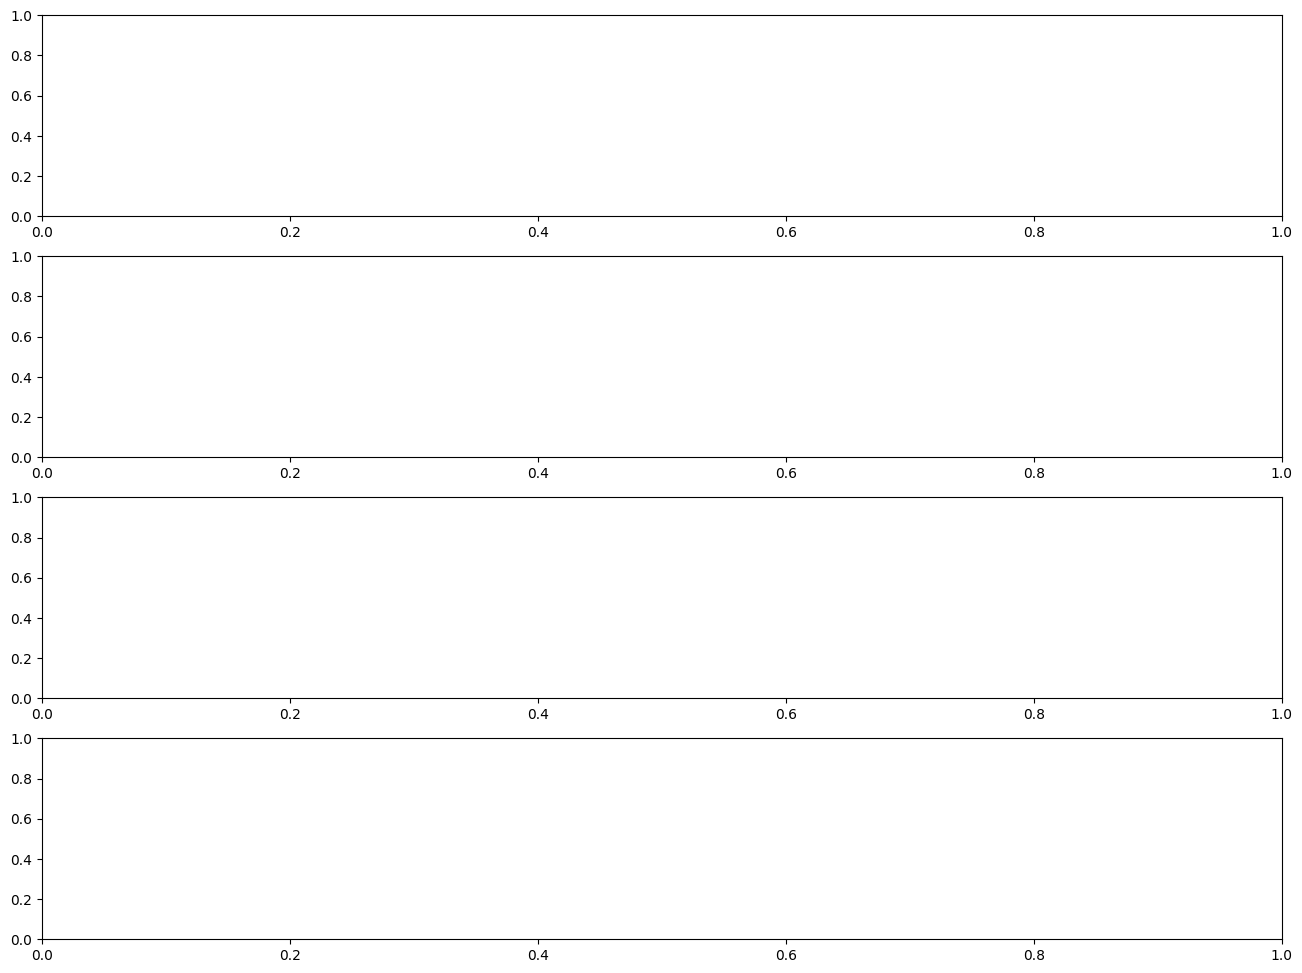

In [29]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net2 = results2['ret_net']
stats2 = stats_from_returns(ret_net2)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1997-2025)")
print("="*70)
for k, v in stats2.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")

# =============================================================================
# 4. ANÁLISE DE NEUTRALIDADE ⭐ NOVO
# =============================================================================

analysis_results2 = analyze_strategy(
    algo_weights=results2['algo_weights'],
    betas=results2['betas'],
    ret_net=results2['ret_net'],
    Factor_PCA=results2['Factor_PCA'],
    pcs=results2['pcs'],
    plot=True,
    title_prefix="[1997-2025] "
)

# =============================================================================
# 5. ANÁLISE POR SUBPERÍODOS (OPCIONAL)
# =============================================================================

print("\n" + "📅 "*35)
print("ANÁLISE POR SUBPERÍODOS")
print("📅 "*35 + "\n")

subperiods2 = [
    ("1999-2002", "1999-01-01", "2002-12-31"),
    ("2003-2007", "2003-01-01", "2007-12-31"),
    ("2008-2012", "2008-01-01", "2012-12-31"),
    ("2013-2017", "2013-01-01", "2017-12-31"),
    ("2018-2022", "2018-01-01", "2022-12-31"),
    ("2023-2025", "2023-01-01", "2025-12-31"),
]

for label, start, end in subperiods2:
    print(f"\n{'='*70}")
    print(f"Subperíodo: {label}")
    print(f"{'='*70}")
    
    mask = (ret_net.index >= start) & (ret_net.index <= end)
    ret_sub = ret_net[mask]
    
    if len(ret_sub) < 100:
        print("⚠️  Dados insuficientes")
        continue
    
    stats_sub = stats_from_returns(ret_sub)
    for k, v in stats_sub.items():
        print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")

## Testando com PC variáveis e Thresholdes variáveis

In [ ]:
returns0 = returns.loc["1998-12-30":"2007-12-28"]
returns_spy0 = returns_spy.loc["1998-12-30":"2007-12-28"]

results3 = pca_portfolio_spy_adaptive_pcs(
    returns = returns0,
    returns_spy = returns_spy0,
    variance_target = 0.60,  
    min_pcs = 5,
    max_pcs = 35,
    s_win = 60,
    adaptive_thresholds = True,
    adaptive_window = 252,
    percentile_open = 0.15,
    percentile_close_short = 0.35,
    percentile_close_long = 0.45,
    # thresholds fixos
    sbo = 1.25,
    sso = 1.25,
    sbc = 0.50,
    ssc = 0.50,
    eps_cost = 0.0005,
    rebalanceamento_dias = 1,
    plot = True,
)

Tempo : 1999-03-29 00:00:00
Tempo : 1999-03-30 00:00:00
Tempo : 1999-03-31 00:00:00
Tempo : 1999-04-01 00:00:00
Tempo : 1999-04-05 00:00:00
Tempo : 1999-04-06 00:00:00
Tempo : 1999-04-07 00:00:00
Tempo : 1999-04-08 00:00:00
Tempo : 1999-04-09 00:00:00
Tempo : 1999-04-12 00:00:00
Tempo : 1999-04-13 00:00:00
Tempo : 1999-04-14 00:00:00
Tempo : 1999-04-15 00:00:00
Tempo : 1999-04-16 00:00:00
Tempo : 1999-04-19 00:00:00
Tempo : 1999-04-20 00:00:00
Tempo : 1999-04-21 00:00:00
Tempo : 1999-04-22 00:00:00
Tempo : 1999-04-23 00:00:00
Tempo : 1999-04-26 00:00:00
Tempo : 1999-04-27 00:00:00
Tempo : 1999-04-28 00:00:00
Tempo : 1999-04-29 00:00:00
Tempo : 1999-04-30 00:00:00
Tempo : 1999-05-03 00:00:00
Tempo : 1999-05-04 00:00:00
Tempo : 1999-05-05 00:00:00
Tempo : 1999-05-06 00:00:00
Tempo : 1999-05-07 00:00:00
Tempo : 1999-05-10 00:00:00
Tempo : 1999-05-11 00:00:00
Tempo : 1999-05-12 00:00:00
Tempo : 1999-05-13 00:00:00
Tempo : 1999-05-14 00:00:00
Tempo : 1999-05-17 00:00:00
Tempo : 1999-05-18 0

In [ ]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net3 = results3['ret_net']
stats3 = stats_from_returns(ret_net3)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2007)")
print("="*70)
for k, v in stats3.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")

# =============================================================================
# 4. ANÁLISE DE NEUTRALIDADE ⭐ NOVO
# =============================================================================

analysis_results3 = analyze_strategy(
    algo_weights=results3['algo_weights'],
    betas=results3['betas'],
    ret_net=results3['ret_net'],
    Factor_PCA=results3['Factor_PCA'],
    pcs=results3['pcs'],
    plot=True,
    title_prefix="[1999-2007] "
)

# =============================================================================
# 5. ANÁLISE POR SUBPERÍODOS (OPCIONAL)
# =============================================================================

print("\n" + "📅 "*35)
print("ANÁLISE POR SUBPERÍODOS")
print("📅 "*35 + "\n")

subperiods3 = [
    ("1999-2002", "1999-01-01", "2002-12-31"),
    ("2003-2007", "2003-01-01", "2007-12-31"),
]

for label, start, end in subperiods3:
    print(f"\n{'='*70}")
    print(f"Subperíodo: {label}")
    print(f"{'='*70}")
    
    mask = (ret_net3.index >= start) & (ret_net3.index <= end)
    ret_sub = ret_net3[mask]
    
    if len(ret_sub) < 100:
        print("⚠️  Dados insuficientes")
        continue
    
    stats_sub = stats_from_returns(ret_sub)
    for k, v in stats_sub.items():
        print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")

In [ ]:
results4 = pca_portfolio_spy_adaptive_pcs(
    returns = returns_longa,
    returns_spy = returns_spy_longa,
    variance_target = 0.60,  
    min_pcs = 5,
    max_pcs = 35,
    s_win = 60,
    adaptive_thresholds = True,
    adaptive_window = 252,
    percentile_open = 0.15,
    percentile_close_short = 0.35,
    percentile_close_long = 0.45,
    # thresholds fixos
    sbo = 1.25,
    sso = 1.25,
    sbc = 0.50,
    ssc = 0.50,
    eps_cost = 0.0005,
    rebalanceamento_dias = 1,
    plot = True,
)

In [ ]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net4 = results4['ret_net']
stats4 = stats_from_returns(ret_net4)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1997-2025)")
print("="*70)
for k, v in stats4.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")

# =============================================================================
# 4. ANÁLISE DE NEUTRALIDADE ⭐ NOVO
# =============================================================================

analysis_results4 = analyze_strategy(
    algo_weights=results4['algo_weights'],
    betas=results4['betas'],
    ret_net=results4['ret_net'],
    Factor_PCA=results4['Factor_PCA'],
    pcs=results4['pcs'],
    plot=True,
    title_prefix="[1997-2025] "
)

# =============================================================================
# 5. ANÁLISE POR SUBPERÍODOS (OPCIONAL)
# =============================================================================

print("\n" + "📅 "*35)
print("ANÁLISE POR SUBPERÍODOS")
print("📅 "*35 + "\n")

subperiods4 = [
    ("1999-2002", "1999-01-01", "2002-12-31"),
    ("2003-2007", "2003-01-01", "2007-12-31"),
    ("2008-2012", "2008-01-01", "2012-12-31"),
    ("2013-2017", "2013-01-01", "2017-12-31"),
    ("2018-2022", "2018-01-01", "2022-12-31"),
    ("2023-2025", "2023-01-01", "2025-12-31"),
]

for label, start, end in subperiods4:
    print(f"\n{'='*70}")
    print(f"Subperíodo: {label}")
    print(f"{'='*70}")
    
    mask = (ret_net4.index >= start) & (ret_net4.index <= end)
    ret_sub = ret_net4[mask]

    if len(ret_sub) < 100:
        print("⚠️  Dados insuficientes")
        continue
    
    stats_sub = stats_from_returns(ret_sub)
    for k, v in stats_sub.items():
        print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")

In [ ]:
#pip install quantstats

In [ ]:
import quantstats as qs

#qs.reports.html(cum_algo, output="relatorio.html", title="Relatório da Estratégia")
